# Анализ датасета online_retail

#### Описание проекта:

В этом проекте я анализирую набор данных, содержащий все транзакции, совершенные в период с 01.12.2010 по 09.12.2011 зарегистрированной в Великобритании компании, занимающейся онлайн-ритейлом (без физических магазинов). Компания в основном продает уникальные подарки на все случаи жизни. Многие клиенты компании являются оптовыми покупателями.

Цель: выявить основные закономерности и подготовить визуализации для принятия бизнес-решений. Далее будут рассматриваться такие показатели, как:
1. Анализ географии продаж (ТОП-10 стран по выручке, доли этих стран в общей выручке компании)
2. Динамика продаж по месяцам
3. Анализ возвратов (общая статистика, доля оптовых (>=500 ед.) и розничных возвратов, ТОП розничных и оптовых возвратов по количеству и суммам, география возвратов)
   
Датасет загружен с Kaggle: https://www.kaggle.com/datasets/ulrikthygepedersen/online-retail-dataset/data

## 1. Очистка и подготовка данных

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-darkgrid') 
sns.set_palette("Set1") 
%matplotlib inline

df = pd.read_csv('online_retail.csv')
df.head(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [3]:
print(f'Размер данных: {df.shape[0]} строк, {df.shape[1]} колонок')
print('\nТипы данных:\n',df.dtypes)
print("\nПропуски:\n", df.isnull().sum())
print("\nСтатистика по числовым колонкам:")
df.describe()

Размер данных: 541909 строк, 8 колонок

Типы данных:
 InvoiceNo       object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID     float64
Country         object
dtype: object

Пропуски:
 InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Статистика по числовым колонкам:


,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [4]:
missing_desc = df[df['Description'].isna()]
missing_desc.sort_values(by = 'UnitPrice', ascending = False).head(15)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.0,NaN,United Kingdom
1970,536545,21134,NaN,1,2010-12-01 14:32:00,0.0,NaN,United Kingdom
1971,536546,22145,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1972,536547,37509,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1987,536549,85226A,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
1988,536550,85044,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
2024,536552,20950,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
2025,536553,37461,NaN,3,2010-12-01 14:35:00,0.0,NaN,United Kingdom
2026,536554,84670,NaN,23,2010-12-01 14:35:00,0.0,NaN,United Kingdom
2406,536589,21777,NaN,-10,2010-12-01 16:50:00,0.0,NaN,United Kingdom


In [47]:
df_new = df.sort_values(by = 'UnitPrice', ascending = True)
df_new.head(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
299983,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,-11062.06,NaN,United Kingdom
299984,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,-11062.06,NaN,United Kingdom
204602,554679,35916A,NaN,-21,2011-05-25 16:04:00,0.00,NaN,United Kingdom
387137,570259,22336,NaN,-114,2011-10-10 09:59:00,0.00,NaN,United Kingdom
387138,570260,35933,NaN,-34,2011-10-10 10:00:00,0.00,NaN,United Kingdom


In [48]:
df_new.tail(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
15016,C537630,AMAZONFEE,AMAZON FEE,-1,2010-12-07 15:04:00,13541.33,NaN,United Kingdom
43703,C540118,AMAZONFEE,AMAZON FEE,-1,2011-01-05 09:57:00,16453.71,NaN,United Kingdom
43702,C540117,AMAZONFEE,AMAZON FEE,-1,2011-01-05 09:55:00,16888.02,NaN,United Kingdom
524602,C580605,AMAZONFEE,AMAZON FEE,-1,2011-12-05 11:36:00,17836.46,NaN,United Kingdom
222681,C556445,M,Manual,-1,2011-06-10 15:31:00,38970.00,15098.0,United Kingdom


In [7]:
print(f"Дубликатов до очистки: {df.duplicated().sum()}")

Дубликатов до очистки: 5268


### Разведочный анализ данных
- Датасет содержит **541 909 транзакций** за период 2010-2011 гг.

### Качество данных
| Показатель | Значение | Комментарий |
|:---|:---|:---|
| Пропуски (CustomerID) | **135 080 записей** (~25%) | Четверть транзакций не привязана к клиентам |
| Пропуски (Description) | **1454** | Вероятно, корректировки остатков |
| Полные дубликаты| **5268** |  |
| Отрицательные Quantity | **+** (мин = -80995) | Возвраты товаров |
| Отрицательные UnitPrice | **+** (мин = -11062) | "Adjust bad debt" - списание безнадежных долгов |
| Экстремально высокие цены | **+** (макс = 38970) | "Manual", "Amazon Fee" -  комиссии и служебные операции |


### Ключевые наблюдения:
1. **Наличие возвратов** - в данных присутствуют как обычные покупки, так и возвраты (отрицательные Quantity). Это важно учитывать при анализе выручки.
2. **Оптовые заказы** — максимальное количество товара в одной транзакции (80 995 ед.) указывает на наличие B2B-клиентов.
3. **Пропуски в идентификаторах** — четверть транзакций не позволяет идентифицировать покупателя, что ограничивает анализ покупательского поведения.
4. **Наличие служебных идентификаторов** - "Manual", "Amazon Fee" и пр. - не относятся к реальным товарам, будут искажать статистику.



### Следующие шаги:
1. Очистить данные от явных аномалий (отрицательные цены), полных дубликатов, пропусков Description (не являются реальными товарами).
2. Отделить возвраты от обычных покупок.
3. Создать признаки для анализа (выручка).
4. Построить базовые визуализации для выявления закономерностей в географии, сезонности и товарном ассортименте.

Пропуски в CustomerID составляют около 25% от размера всего датасета, но было решено оставить строки с этими пропусками, так как при дальнейшем анализе привязка к клиентам не важна.

#### Ограничения исследования и направления для улучшения

Выявлены позиции, не являющиеся товарами в прямом смысле (`Manual`, `POSTAGE`, `AMAZON FEE` и др.). В рамках данного проекта эти записи были сохранены в выборке, чтобы продемонстрировать реальное качество исходных данных.

**Рекомендация на будущее:**

Для повышения точности анализа рекомендуется разработать систему классификации транзакций, которая позволит на этапе предобработки отделять:
1.  Реальные товары (основной анализ)
2.  Служебные и бухгалтерские проводки (анализировать отдельно, если потребуется)
3.  Логистические и комиссионные сборы (для анализа издержек)

Это позволит получать более чистые данные для анализа покупательского поведения и ассортимента.

### Очистка данных

In [8]:
df_clean = df.copy()
print(f'Начальный размер данных: {df_clean.shape[0]} строк, {df_clean.shape[1]} колонок\n')

df_clean = df_clean[df_clean['UnitPrice']>0]
print(f'После удаления строк с отрицательными значениями цены (аномалий): {len(df_clean)} строк')
df_clean = df_clean.drop_duplicates()
print(f'После удаления полных дубликатов: {len(df_clean)} строк')
df_clean = df_clean.dropna(subset = ['Description'])
print(f'После удаления пропусков в Description: {len(df_clean)} строк')
#Создаем колонку с выручкой
df_clean['Revenue'] = df_clean['Quantity']*df_clean['UnitPrice']
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate']) #преобразуем object в datetime
df_clean['YearMonth'] = df_clean['InvoiceDate'].dt.to_period('M') 
print(f'\nПОСЛЕ ПРЕОБРАЗОВАНИЙ: {df_clean.shape[0]} строк, {df_clean.shape[1]} колонок')

df_clean.head()

Начальный размер данных: 541909 строк, 8 колонок

После удаления строк с отрицательными значениями цены (аномалий): 539392 строк
После удаления полных дубликатов: 534129 строк
После удаления пропусков в Description: 534129 строк

ПОСЛЕ ПРЕОБРАЗОВАНИЙ: 534129 строк, 10 колонок


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,YearMonth
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010-12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010-12
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12


### Статистика после очистки:


In [9]:
df_clean.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID,Revenue
count,534129.000000,534129,534129.000000,401564.000000,534129.000000
mean,9.916818,2011-07-04 12:02:01.631403776,4.695864,15281.266797,18.250518
min,-80995.000000,2010-12-01 08:26:00,0.001000,12346.000000,-168469.600000
25%,1.000000,2011-03-28 11:36:00,1.250000,13939.000000,3.750000
50%,3.000000,2011-07-19 15:55:00,2.100000,15145.000000,9.900000
75%,10.000000,2011-10-18 17:10:00,4.130000,16788.000000,17.570000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000,168469.600000
std,216.452113,NaN,95.079189,1713.978947,380.945385


#### Очистка данных 
Выполненные шаги:
1. Удаление пропусков Description
2. Удаление  отрицательных знач. цены
3. Удаление полных дубликатов
4. Создание колонки Revenue
5. Преобразование object в datetime в колонке с датой и добавление колонки YearMonth

#### Обоснование

**1. Удаление пропусков Description:** это корректировки остатков.

**2. Удаление отрицательных значений цены:** это списание безнадежных долгов.

**3. Удаление полных дубликатов:** дубликаты засоряют выборку и искажают статистику. 

**4. Создание колонки Revenue:** добавили признак выручки для дальнейшего анализа. 

**5. Преобразование object в datetime в колонке с датой и добавление колонки YearMonth:** необходимо для дальнейшего анализа динамики продаж по месяцам.

### Итоговый датасет:

In [10]:
print(f'Размер: {df_clean.shape[0]} строк, {df_clean.shape[1]} колонок')

min_data =  min(df_clean['InvoiceDate'])
max_data =  max(df_clean['InvoiceDate'])
print(f'Диапазон дат с {min_data} по {max_data}')

Размер: 534129 строк, 10 колонок
Диапазон дат с 2010-12-01 08:26:00 по 2011-12-09 12:50:00


#### Примечание:

В данных сохранены **отрицательные значения Quantity (возвраты)**. Они будут анализироваться отдельно. 

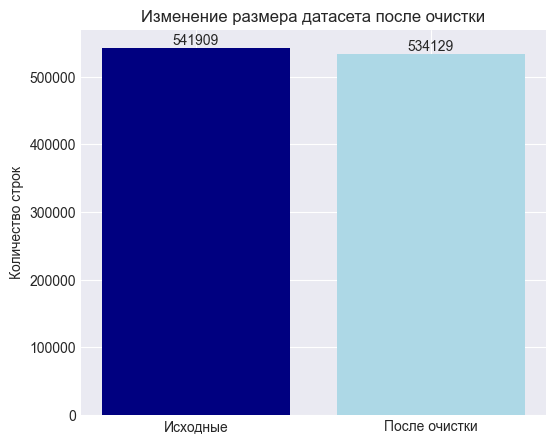

In [11]:
# Визуализация потерь данных
steps = ['Исходные', 'После очистки']
counts = [len(df), len(df_clean)]
plt.figure(figsize=(6, 5))
plt.bar(steps, counts, color=['navy', 'lightblue'])
plt.title('Изменение размера датасета после очистки')
plt.ylabel('Количество строк')
for i, v in enumerate(counts):
    plt.text(i, v + 5000, str(v), ha='center')
plt.show()

## 2. Анализ географии продаж


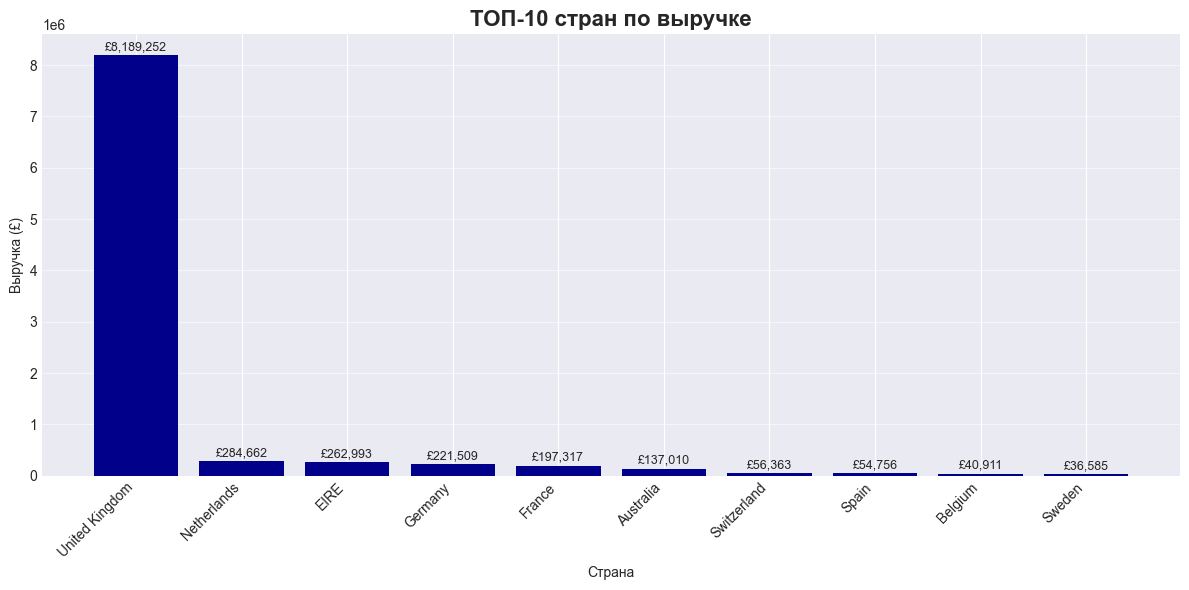

In [12]:
country_revenue = df_clean.groupby('Country')['Revenue'].sum().sort_values(ascending = False).head(10)
plt.figure(figsize = (12,6))
bars = plt.bar(range(len(country_revenue)), country_revenue.values, color = 'darkblue')
plt.xticks(range(len(country_revenue)), country_revenue.index, rotation = 45, ha = 'right')
plt.title('ТОП-10 стран по выручке', fontsize = 16, fontweight = 'bold')
plt.xlabel('Страна')
plt.ylabel('Выручка (£)')

for i, (bar, val) in enumerate(zip(bars, country_revenue.values)):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100000, 
             f'£{val:,.0f}', ha='center', fontsize=9)
plt.grid(axis='y', alpha=0.6)

plt.tight_layout()
plt.show()

In [13]:
top10 = country_revenue.sum()
only_uk = (country_revenue['United Kingdom'] / top10) * 100
print(f"Первое место: {country_revenue.index[0]} - £{country_revenue.values[0]:,.0f} ({country_revenue.values[0]/top10*100:.1f}% от топ-10)")
print(f"Второе место: {country_revenue.index[1]} - £{country_revenue.values[1]:,.0f} ({country_revenue.values[1]/top10*100:.1f}% от топ-10)")
print(f"Третье место: {country_revenue.index[2]} - £{country_revenue.values[2]:,.0f} ({country_revenue.values[2]/top10*100:.1f}% от топ-10)")

Первое место: United Kingdom - £8,189,252 (86.4% от топ-10)
Второе место: Netherlands - £284,662 (3.0% от топ-10)
Третье место: EIRE - £262,993 (2.8% от топ-10)


#### Интерпретация и рекомендации по анализу географии продаж:
*Примечание: помним о том, что мы анализируем данные за 2010-2011 годы, в то время рынок онлайн-торговли был развит неравномерно, последствия экономического кризиса 2008 года все еще могли давать о себе знать, а также международные онлайн-платежи были далеки от сегодняшней простоты - существовали серьёзные технические, юридические и инфраструктурные барьеры.*

***Ключевые наблюдения:***

Первое место со значительным отрывом занимает Великобритания (86.4% выручки ТОП-10 стран) - это ожидаемо для компании, которая находится в Великобритании. Вероятно, компания фокусируется на внутреннем рынке, такой высокий показатель может указывать на:
1. Более быструю и дешевую доставку внутри страны
2. Отсутствие языкового барьера
3. Адаптация ассортимента товаров под потребности покупателей внутри страны (традиции, праздники)
4. Активная реклама

***Следующие крупнейшие европейские континентальные рынки:***

Нидерланды (284.662£), Ирландия (262.993£), Германия (221.509£) - выручка значительно ниже, чем в Великобритании, но это крупнейшие внешние рынки.
Возможные причины:
1. Географическая близость с Великобританией
3. Для Нидерландов и Ирландии - отсутствие языкового барьера, схожие платежные системы.
4. Для Ирландии - схожая культура и традиции

Германию и Францию я бы назвала проблемными зонами, так как эти страны являются (и в те годы тоже являлись) крупнейшими экономиками Европы, соответственно их потенциал гораздо выше, чем мы имеем в результате. 

К возможным причинам низких продаж можно отнести:
1. Языковой барьер. Скорее всего сайт ритейлера в те годы был только на английском, а онлайн-перевод работал несовершено.
2. Последствия экономического кризиса 2008 года были все еще ощутимы для населения.
3. Во Франции в 2010 году всё еще преобладали местные рынки и небольшие магазины.
4. В Германии уже были сильные местные онлайн-площадки.
5. Проблемы с оплатой онлайн между разными странами (комиссии, несовместимость платежных систем и т.д.)

#### Австралия - единственная неевропейская страна в ТОП-10, и она занимает 6 место.

Анализ географии выявил уникальную аномалию - из 10 стран с наибольшей выручкой 9 находятся в Европе, и лишь Австралия - на другом конце света.
- Расстояние от Австралии до Великобритании около 17 000 км (долгая и дорогая логистика)
- Население около 22 млн человек, что меньше, чем население Испании, Германии и Франции

***Возможные причины аномалии, с учетом контекста 2010-2011 годов:***

1. Платежная совместимость (карточные рынки Великобритании и Австралии в те годы имели схожую структуру, отличаясь от континентальной Европы)
2. Отсутствие языкового барьера
3. Общие культурные ценности и традиции из-за исторических связей
4. Австралия входила в число мировых лидеров по ВВП на душу населения, опережая многие крупные европейские экономики


### Рекомендации для бизнеса

***Для Великобритании:***

Рынок уже дает 86.4% выручки - важно удерживать позиции.
1. Укреплять логистику внутри страны
2. Анализировать сезонность и локальные праздники, чтобы вовремя увеличивать запасы под всплески спроса
3. Собирать обратную связь от постоянных клиентов (для понимания сильных сторон компании, а также выявления неочевидных точек роста)

***Для Нидерландов и Ирландии:***

1. Увеличить рекламный бюджет в этих странах
2. Проанализировать, какие товары покупают чаще всего и выделить их в отдельную подборку
3. Проанализировать возможности ускоренной доставки

***Для Германии и Франции:***
1. Языковой барьер - главная гипотеза. Перевести сайт на немецкий и французский.
2. Добавить локальные способы оплаты
3. Проанализировать возможности ускоренной доставки
4. Изучить цены и ассортимент местных конкурентов

***Для Австралии:***
1. Выделить австралийских клиентов в отдельную группу, чтобы изучать их поведение отдельно от европейских
2. Проанализировать, какие именно товары они покупают - возможно, расширить ассортимент в определенных категориях
3. Рассмотреть возможность партнерства с местным оператором или открытие локальной точки - для снижения стоимости логистики

***Для остальных европейских стран из ТОП-10:***
1. Поддерживать текущий уровень без больших инвестиций
2. При локализации сайта для крупных рынков (Германия, Франция) автоматически охватывать и это страны (для Бельгии, Швейцарии - французский и немецкий, для Швейцарии и Испании английский пока достаточен)
3. По возможности тоже добавить локальные платежные системы
4. Отслеживать динамику - если после локализации сайта и\или добавления платежных систем эти страны покажут рост - усилить внимание

***Общие рекомендации (для всех стран):***

1. Собирать информацию о способах оплаты для будущих рынков
2. Анализировать конверсию по странам для выявления проблемных зон

## 3. Динамика продаж по месяцам

*Декабрь 2011 был исключен из анализа пиковых значений, так как в датасете он представлен только частично (1-9 декабря). Это позволит избежать некорректного сравнения неполного месяца с полными.*


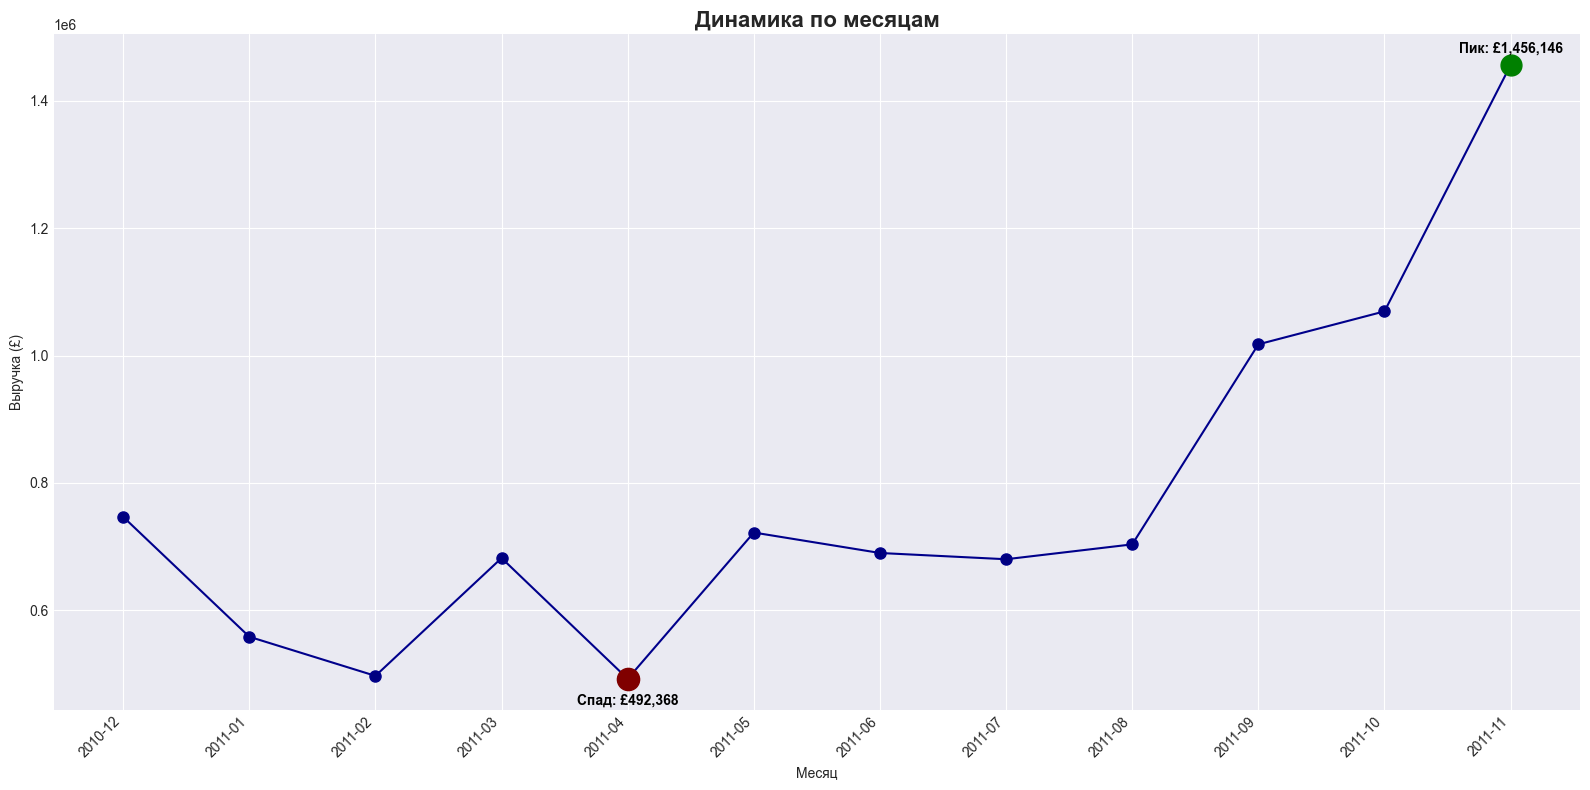

In [14]:
monthly_revenue = df_clean.groupby('YearMonth')['Revenue'].sum()
monthly_revenue_full = monthly_revenue.drop('2011-12')
plt.figure(figsize = (16,8))
plt.plot(monthly_revenue_full.index.astype(str), monthly_revenue_full.values, 
         marker='o', markersize=8, color='darkblue', markerfacecolor='navy')

plt.xticks(rotation = 45, ha = 'right')
plt.title('Динамика по месяцам', fontsize = 16, fontweight = 'bold')
plt.xlabel('Месяц')
plt.ylabel('Выручка (£)')

max_month = monthly_revenue_full.idxmax()
max_value = monthly_revenue_full.max()
min_month = monthly_revenue_full.idxmin()
min_value = monthly_revenue_full.min()

x_positions = range(len(monthly_revenue_full))
max_idx = monthly_revenue_full.index.tolist().index(max_month)
min_idx = monthly_revenue_full.index.tolist().index(min_month)

plt.plot(x_positions[max_idx], max_value, 'o', markersize=15, markerfacecolor='green', markeredgecolor = 'green')
plt.plot(x_positions[min_idx], min_value, 'o', markersize=16, markerfacecolor='maroon', markeredgecolor='maroon')


plt.text(max_idx, max_value + 20000, f'Пик: £{max_value:,.0f}', ha='center', color='black', fontweight='bold')
plt.text(min_idx, min_value - 40000, f'Спад: £{min_value:,.0f}', ha='center', color='black', fontweight='bold')

plt.tight_layout()
plt.show()


#### Интерпретация и рекомендации: ####

1. Пик продаж - ноябрь 2011 (£ 1 456 146)
Это объясняется несколькими факторами:
- Черная пятница - крупнейшая распродажа года в конце ноября
- Сезонная подготовка - новогодний и рождественский декор
- Многие покупают подарки на декабрьские праздники заранее

2. Месяцы с ощутимым ростом относительно предыдущего месяца:

| Месяц | Возможная причина |
| :-----:|:---:|
| Март  | Подготовка к 8 марта и дню матери в Великобритании (в 2011 году выпал на 3 апреля, вероятно подарки покупали заранее) |
| Май | Дни рождения, сезонные праздники (майский день в первую неделю мая), начало летнего сезона |
|Сентябрь | Подготовка в осени, начало учебного года |
| Ноябрь | Черная пятница, предновогодняя активность |

3. Причины спада в другие месяцы

| Месяц | Возможная причина |
| :-----:|:---:|
| Январь  | "Январское затишье" - изменение финансовых приоритетов потребителей |
| Февраль | Нет крупных праздников, короткий месяц |
| Апрель | см. ниже |
| Июнь-август | Сезон отпусков, траты смещаются на сферу туризма |
|Октябрь |Накопление перед предстоящими тратами в ноябре-декабре|

**Апрель показал самую низкую выручку за 2011 год, возможные причины:**
- Пасха в 2011 году пришлась на 24 апреля, но люди покупают продукты и подарки заранее - соответственно основная часть трат сместилась на март
- Длинные выходные (Пасха, bank holidays в конце апреля в Велиробритании) - люди не сидят дома за онлайн-покупками
- Эффект после мартовких праздников - закономерное затишье
- Высокая доля возвратов в этом месяце


4. Примерное сравнение декабря 2010 и декабря 2011:

In [15]:
print('Выручка за декабрь 2010 (1.12-31.12): £',monthly_revenue[monthly_revenue.index[0]])
print('Выручка за декабрь 2011 (1.12-9.12): £',monthly_revenue[monthly_revenue.index[len(monthly_revenue)-1]])

Выручка за декабрь 2010 (1.12-31.12): £ 746723.61
Выручка за декабрь 2011 (1.12-9.12): £ 432701.06


Выручка за первые 9 дней декабря 2011 года всего лишь на 314 тыс £ меньше, чем выручка за полный месяц декабрь предыдущего года. 
При самой грубой оценке (умножение выручки за 1-9 декабря на 3,3 для получения предполагаемого значения за полный месяц) выручка за декабрь 2011 получается более 1.4 млн £.
Скорее всего, при полных данных за декабрь 2011 г. этот месяц либо стал бы пиковым по выручке, либо был бы на уровне ноября, что значительно выше, чем декабрь 2010 года. 

**Итоговые выводы по динамике за год:**
* Бизнес демонстрирует уверенный рост выручки с июля 2011 года. 
* Основные всплески за 2011 год: март, май, сентябрь и ноябрь.
* Наиболее ощутимый спад: январь и апрель.
* При полных данных декабрь 2011 вероятно стал бы лидером по выручке, что демонстрирует важность первой половины декабря для онлайн-торговли.

#### Рекомендации для бизнеса:

1. Увеличивать остатки и рекламный бюджет: март, сентябрь, ноябрь, декабрь
2. Проводить акции: январь-февраль, апрель, летний сезон (июнь-июль)
3. Проанализировать, что именно покупали в пиковые месяцы


## 4. Анализ возвратов

**Общая статистика возвратов:**

In [45]:
df_returns = df_clean[df_clean['Quantity'] < 0].copy()  # копируем возвраты(отрицательные quantity) в df_returns

df_returns['ReturnAmount'] = abs(df_returns['Revenue']) # приводим к модулю сумму возвратов

print(f"Количество возвратов: {len(df_returns)} транзакций")
print(f"Доля возвратов: {len(df_returns)/len(df_clean)*100:.2f}% всех транзакций")
print(f"Сумма возвратов: £{df_returns['ReturnAmount'].sum():,.2f}")
print(f"Доля в выручке: {df_returns['ReturnAmount'].sum()/df_clean[df_clean['Quantity'] > 0]['Revenue'].sum()*100:.2f}%")
print(f"Средний чек возврата: £{df_returns['ReturnAmount'].mean():.2f}")
print(f"Средний чек покупки: £{(df_clean[df_clean['Quantity']>0]['Revenue']).mean():.2f}")

Количество возвратов: 9251 транзакций
Доля возвратов: 1.73% всех транзакций
Сумма возвратов: £893,979.73
Доля в выручке: 8.40%
Средний чек возврата: £96.64
Средний чек покупки: £20.28


**Рассмотрим статистику по розничным и оптовым (Quantity >= 500 ед.) возвратам отдельно**

*Оптовые:*

In [17]:
opt = 500
df_returns_opt = df_returns[df_returns['Quantity'].abs() >= opt].copy()

print(f"Количество транзакций: {len(df_returns_opt)}")
print(f"Сумма возвратов: £{df_returns_opt['ReturnAmount'].sum():,.2f}")
print(f"Средняя сумма возврата: £{df_returns_opt['ReturnAmount'].mean():.2f}")
print(f"Медианная сумма: £{df_returns_opt['ReturnAmount'].median():.2f}")

print(f"\nДоля оптовых возвратов в общей сумме: {df_returns_opt['ReturnAmount'].sum() / df_returns['ReturnAmount'].sum() * 100:.1f}%")

Количество транзакций: 28
Сумма возвратов: £287,843.07
Средняя сумма возврата: £10280.11
Медианная сумма: £1080.00

Доля оптовых возвратов в общей сумме: 32.2%




*Розничные:*

In [18]:
opt = 500
df_returns_rz = df_returns[df_returns['Quantity'].abs() < opt].copy()

print(f"Количество транзакций: {len(df_returns_rz)}")
print(f"Сумма возвратов: £{df_returns_rz['ReturnAmount'].sum():,.2f}")
print(f"Средняя сумма возврата: £{df_returns_rz['ReturnAmount'].mean():.2f}")
print(f"Медианная сумма: £{df_returns_rz['ReturnAmount'].median():.2f}")

print(f"\nДоля розничных возвратов в общей сумме: {df_returns_rz['ReturnAmount'].sum() / df_returns['ReturnAmount'].sum() * 100:.1f}%")

Количество транзакций: 9223
Сумма возвратов: £606,136.66
Средняя сумма возврата: £65.72
Медианная сумма: £8.50

Доля розничных возвратов в общей сумме: 67.8%


**Визуализация долей оптовых и розничных возвратов**

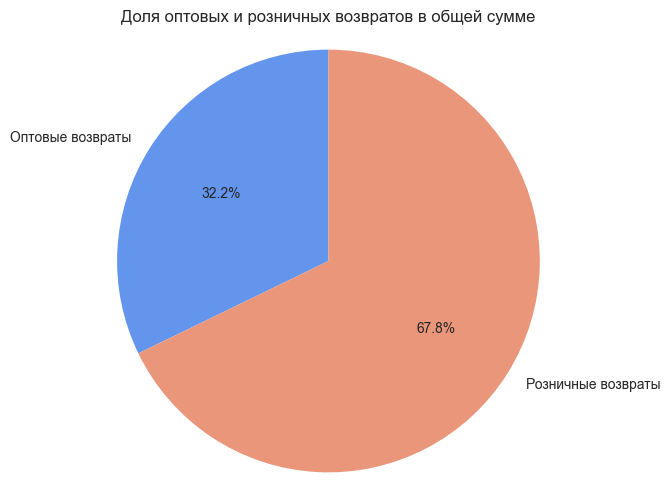

In [19]:
 
opt_share = df_returns_opt['ReturnAmount'].sum() / df_returns['ReturnAmount'].sum() * 100
rz_share = df_returns_rz['ReturnAmount'].sum() / df_returns['ReturnAmount'].sum() * 100
sizes = [opt_share, rz_share]
labels = ['Оптовые возвраты','Розничные возвраты']
colors = ['cornflowerblue','darksalmon']
plt.figure(figsize=(6,6))
plt.pie(sizes, labels = labels, colors = colors, autopct='%1.1f%%', startangle=90)
plt.title('Доля оптовых и розничных возвратов в общей сумме')
plt.axis('equal') 
plt.show()

**Топ товаров по оптовым возвратам**

In [20]:
top_returned_qty = df_returns_opt.groupby('Description')['Quantity'].sum().abs().sort_values(ascending=False).head(10) # возвращают чаще всего по кол-ву

top_returned_amount = df_returns_opt.groupby('Description')['ReturnAmount'].sum().sort_values(ascending=False).head(10) # возвращают чаще всего по сумме

print("ТОП-10 товаров по количеству оптовых возвратов: \n")
print(top_returned_qty.to_string())

print("\nТОП-10 товаров по сумме оптовых возвратов: \n")
print(top_returned_amount.to_string())

ТОП-10 товаров по количеству оптовых возвратов: 

Description
PAPER CRAFT , LITTLE BIRDIE            80995
MEDIUM CERAMIC TOP STORAGE JAR         74215
ROTATING SILVER ANGELS T-LIGHT HLDR     9360
FAIRY CAKE FLANNEL ASSORTED COLOUR      3114
WHITE HANGING HEART T-LIGHT HOLDER      2430
GIN + TONIC DIET METAL SIGN             2000
Manual                                  1950
HERB MARKER BASIL                       1515
FELTCRAFT DOLL MOLLY                    1440
TEA TIME PARTY BUNTING                  1300

ТОП-10 товаров по сумме оптовых возвратов: 

Description
PAPER CRAFT , LITTLE BIRDIE           168469.60
MEDIUM CERAMIC TOP STORAGE JAR         77183.60
FAIRY CAKE FLANNEL ASSORTED COLOUR      6539.40
WHITE HANGING HEART T-LIGHT HOLDER      6196.50
DOORMAT FAIRY CAKE                      4522.50
PANTRY CHOPPING BOARD                   3825.36
GIN + TONIC DIET METAL SIGN             3700.00
FELTCRAFT DOLL MOLLY                    3492.00
TEA TIME PARTY BUNTING                  3315.0

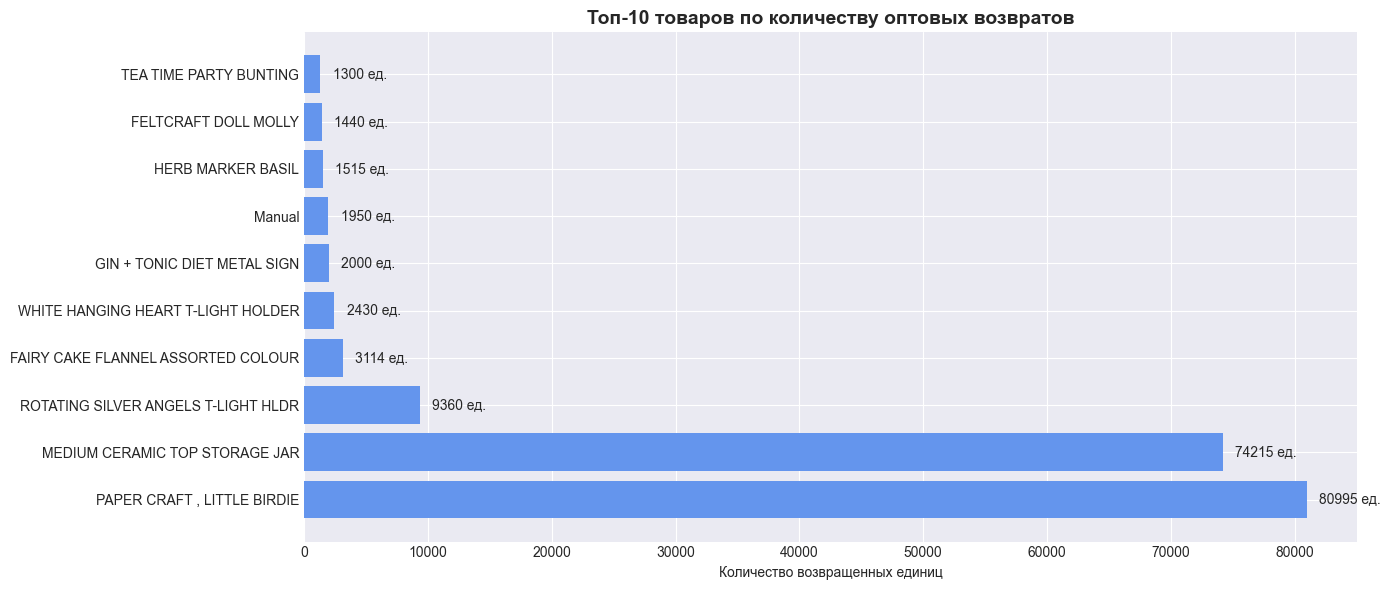

In [21]:
top_returned = df_returns_opt.groupby('Description')['Quantity'].sum().abs().sort_values(ascending=False).head(10)

plt.figure(figsize=(14, 6))

bars = plt.barh(range(len(top_returned)), top_returned.values, color='cornflowerblue')
plt.yticks(range(len(top_returned)), top_returned.index)
plt.title('Топ-10 товаров по количеству оптовых возвратов', fontsize=14, fontweight='bold')
plt.xlabel('Количество возвращенных единиц')

for i, (bar, val) in enumerate(zip(bars, top_returned.values)):
    plt.text(bar.get_width() + 1000, bar.get_y() + bar.get_height()/2, 
             f'{int(val)} ед.', va='center')

plt.tight_layout()
plt.show()

**Топ товаров по розничным возвратам**

In [22]:
top_returned_qty_rz = df_returns_rz.groupby('Description')['Quantity'].sum().abs().sort_values(ascending=False).head(10) # возвращают чаще всего по кол-ву

top_returned_amount_rz = df_returns_rz.groupby('Description')['ReturnAmount'].sum().sort_values(ascending=False).head(10) # возвращают чаще всего по сумме

print("ТОП-10 товаров по количеству розничных возвратов: \n")
print(top_returned_qty_rz.to_string())

print("\nТОП-10 товаров по сумме розничных возвратов: \n")
print(top_returned_amount_rz.to_string())

ТОП-10 товаров по количеству розничных возвратов: 

Description
Manual                               2116
COLOUR GLASS. STAR T-LIGHT HOLDER    1174
JUMBO BAG RED RETROSPOT              1115
PLACE SETTING WHITE HEART             890
REGENCY CAKESTAND 3 TIER              855
JUMBO BAG APPLES                      723
REVOLVER WOODEN RULER                 716
GIRAFFE WOODEN RULER                  714
JUMBO BAG ALPHABET                    594
FLOWERS CHANDELIER T-LIGHT HOLDER     579

ТОП-10 товаров по сумме розничных возвратов: 

Description
AMAZON FEE                           235281.59
Manual                               146454.46
POSTAGE                               11871.24
REGENCY CAKESTAND 3 TIER               9697.05
CRUK Commission                        7933.43
Bank Charges                           7340.64
Discount                               5689.02
COLOUR GLASS. STAR T-LIGHT HOLDER      3246.16
SAMPLES                                3102.70
IVORY DINER WALL CLOCK           

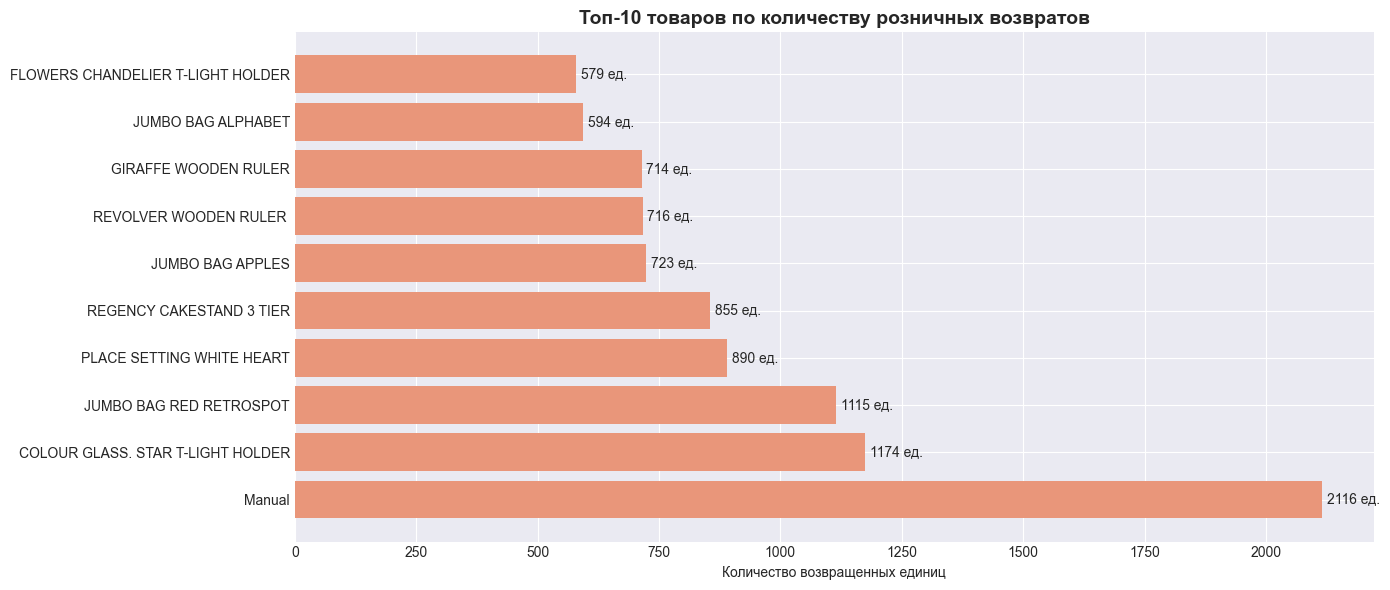

In [23]:
top_returned = df_returns_rz.groupby('Description')['Quantity'].sum().abs().sort_values(ascending=False).head(10)

plt.figure(figsize=(14, 6))
bars = plt.barh(range(len(top_returned)), top_returned.values, color='darksalmon')
plt.yticks(range(len(top_returned)), top_returned.index)
plt.title('Топ-10 товаров по количеству розничных возвратов', fontsize=14, fontweight='bold')
plt.xlabel('Количество возвращенных единиц')

for i, (bar, val) in enumerate(zip(bars, top_returned.values)):
    plt.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2, 
             f'{int(val)} ед.', va='center')

plt.tight_layout()
plt.show()

Выясним, в какой стране производились самые крупные оптовые возвраты (для понимания влияния этих значений на анализ):

In [24]:
df_clean[((df_clean['Description'] == 'PAPER CRAFT , LITTLE BIRDIE')|(df_clean['Description'] == 'MEDIUM CERAMIC TOP STORAGE JAR'))
    &(df_clean['Quantity'] < -70000)]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,YearMonth
61624,C541433,23166,MEDIUM CERAMIC TOP STORAGE JAR,-74215,2011-01-18 10:17:00,1.04,12346.0,United Kingdom,-77183.6,2011-01
540422,C581484,23843,"PAPER CRAFT , LITTLE BIRDIE",-80995,2011-12-09 09:27:00,2.08,16446.0,United Kingdom,-168469.6,2011-12


Оба эти возврата были произведены в Великобритании. В целом, можно продолжить анализ с учетом этих двух возвратов, но из-за своих аномально больших значений они могут сильно искажать общую статистику возвратов в Великобритании, поэтому вычислим долю возвратов в Великобритании "с" и "без" этих двух значений и сравним результаты.

In [43]:
uk_returns = df_clean[(df_clean['Country'] == 'United Kingdom') & (df_clean['Quantity'] < 0)].copy() # все возвраты в UK
uk_returns = uk_returns.sort_values(by = 'Quantity', ascending = True)# сортируем таблицу от самого бОльшего количества возвратов к меньшему
total_returns_uk = abs(uk_returns['Revenue'].sum()) # считаем сумму всех возвратов в UK (значение по модулю)
top_2_returns = abs(uk_returns.head(2)['Revenue'].sum()) # считаем сумму двух крупнейших возвратов
total_sales_uk = df_clean[(df_clean['Country'] == 'United Kingdom') & (df_clean['Quantity'] > 0)]['Revenue'].sum() # общие продажи

print(f'Текущая доля возвратов: {total_returns_uk/total_sales_uk * 100:,.2f}%\n')
print(f'Доля возвратов без двух крупнейших: {(total_returns_uk-top_2_returns)/total_sales_uk * 100:,.2f}%')

Текущая доля возвратов: 9.03%

Доля возвратов без двух крупнейших: 6.30%


**Рассмотрим отношение суммы возвратов к объёму продаж по странам (10 стран с наибольшей выручкой):**

In [38]:
returns_by_country = df_returns.groupby('Country')['ReturnAmount'].sum().sort_values(ascending=False).head(10)

for country, amount in returns_by_country.items():
    sales = df_clean[(df_clean['Country'] == country)&(df_clean['Quantity'] > 0)]['Revenue'].sum()
    returns = returns_by_country[country]
    if sales > 0:
        print(f'{country}: £{amount:,.2f}, доля: {returns/sales*100:.2f}%')

United Kingdom: £812,491.79, доля: 9.03%
EIRE: £20,147.14, доля: 7.12%
France: £12,308.26, доля: 5.87%
Singapore: £12,158.90, доля: 57.14%
Germany: £7,168.93, доля: 3.13%
Spain: £6,802.53, доля: 11.05%
Hong Kong: £5,574.76, доля: 36.01%
Portugal: £4,380.08, доля: 13.00%
Japan: £2,075.75, доля: 5.55%
USA: £1,849.47, доля: 51.66%


Отсортируем страны по доле возвратов и выведем первые 10 значений, чтобы посмотреть, в каких странах высокий процент возвратов. 

In [42]:
sales_data = df_clean[df_clean['Quantity'] > 0]
sales = sales_data.groupby('Country')['Revenue'].sum()
returns = df_returns.groupby('Country')['ReturnAmount'].sum()

returns_share = pd.DataFrame({
    'Продажи': sales,
    'Возвраты': returns }).fillna(0)
returns_share['Доля_возвратов'] = (returns_share['Возвраты'] / returns_share['Продажи'] * 100).round(2)
returns_share = returns_share.sort_values('Доля_возвратов', ascending=False).head(10)

print(returns_share)

                    Продажи   Возвраты  Доля_возвратов
Country                                               
Singapore         21279.290   12158.90           57.14
USA                3580.390    1849.47           51.66
Hong Kong         15483.000    5574.76           36.01
Bahrain             754.140     205.74           27.28
Czech Republic      826.740     119.02           14.40
Portugal          33683.050    4380.08           13.00
Spain             61558.560    6802.53           11.05
Saudi Arabia        145.920      14.75           10.11
United Kingdom  9001744.094  812491.79            9.03
Malta              2725.590     220.12            8.08


### Интерпретация и рекомендации по анализу возврата товаров

**1. Общая статистика**

Количество возвратов: 9251 транзакций

Доля возвратов: 1.73% всех транзакций

Сумма возвратов: £893,979.73

Доля в выручке: 8.40%

Средний чек возврата: £96.64

Средний чек покупки: £20.28

**2. Оптовые VS розничные возвраты**

|  | Оптовые | Розничные |
| :----: | :----: |:----:| 
|Количество транзакций| 28|9223 |
| Сумма возвратов |£287 843.07 | £606 136.66 | 
| Средняя сумма  |£10 280.11 |£65.72 |
| Медианная сумма |£1080.00|£8.50|
|Доля в общей сумме|32.2%|67.8%|

Всего 28 оптовых возвратов (0,003% от общего количества возвратов) дают 32.2% суммы всех возвратов. Средняя сумма оптового возврата почти в 157 раз выше розничного. Медианная сумма значительно ниже средней - это указывает на то, что совершались очень крупные возвраты.

**3. Товары-лидеры по возвратам**

*Оптовые*: 
|Товар | Кол-во | Сумма|
|:----:|:----:|:----:|
|MEDIUM CERAMIC TOP STORAGE JAR| 74215 | £77183.6|
|PAPER CRAFT , LITTLE BIRDIE | 80995 | £168469.6|
|Остальные из ТОП-10|от 1140 до 9360 | от £2747.52 до £6539.40|

Оба крупнейших возврата приходятся на Великобританию. 

*Крупнейшие розничные возвраты (по сумме и количеству)*:
|Товар | Кол-во | Сумма|
|:----:|:----:|:----:|
|AMAZON FEE|-|235281.59|
|Manual|2116|146454.46|
|COLOUR GLASS. STAR T-LIGHT HOLDER   | 1174|3246.16|
|POSTAGE| - | 11871.24 |
|REGENCY CAKESTAND 3 TIER |855|9697.05|
|CRUK Commission|-|7933.43|
|Discount | - |5689.02|

Важно учесть, что в топе возвратов розничных товаров встречаются такие позиции как Amazon Fee, Manual, POSTAGE, CRUK Commission, Discount. Такие позиции являются не товарами, а услугами (доставка, комиссии и пр.), поэтому искажают статистику возвратов. 

**Для более точного анализа возвратов и продаж в целом рекомендуется:**

- исключать такие позиции из расчетов

или

- выделять их в отдельню категорию "Услуги" или "Прочее" и анализировать отдельно

Часть товаров из топа относятся к катерогии хрупких товаров, поэтому можно предположить, что причина возвратов таких товаров - повреждения при транспортировке (требуется изучить причины возвратов). 

Рекомендации для снижения доли возвратов по хрупким товарам:
- улучшить упаковку (пузырчатая пленка, дополнительные коробки, наклейки "Хрупкое")
- проанализировать, какие службы доставки чаще повреждают такие товары
- вывести на сайте предупреждение о хрупкости товара и особенностях транспортировки
- внедрить сбор причин возврата товаров

Общие рекомендации для товаров из топа возвратов:
- проанализировать отзывы покупателей
- проверить качество упаковки
- проверить полноту и точность описания товаров на сайте


**4. География возвратов**

Доля возвратов в США и Сингапуре превышает 50%. Приведу некоторые гипотезы, почему могли появится такие значения, для точных выводов необходим анализ этих двух стран отдельно:
- Возвраты товаров, купленных не в этом периоде
- Техническая ошибка или ошибка учета
- Повреждения товаров при транспортировке

Рекомендации по Синагпуру и США:
- проанализировать возвраты товаров за всё время и выяснить, изменится ли доля
- измерять долю возвратов товаров ежемесячно
- если причины возвратов - повреждения при транспортировке, то необходимо пересмотреть упаковку, возможно - сменить транспортную компанию или ввести штрафы за порчу товара


Стоит обратить внимание на ***Португалию, Испанию и Гонконг***, так как это следующие страны из списка, где большое количество продаж сочетается с высокой долей возвратов. Выявить, какие товары чаше всего возвращают и причины возвратов (брак, долгая доставка, повреждения при транспортировке, несоответствие описания товара ожиданиям).

Остальные страны с высокой долей возвратов *(Бахрейн, Чехия, Саудовская Аравия)* - держать на контроле, из-за малого количества продаж пока сложно сделать выводы.

Доля возвратов в Великобритании дополнительно рассчитывалась без двух крупнейших оптовых возвратов и было выяснено, что эти два возврата повышают общий процент на 2.73%. Без аномальных значений доля возвратов в Великобритании составляет 6.30%, что является хорошим показателем для такого крупного рынка. Это подтверждает, что возвраты в Великобритании связаны не с массовым недовольством покупателей, а с единичными оптовыми операциями.


Рекомендации:
- провести анализ причины крупнейших возвратов: выяснить, был ли это брак, ошибка в заказе или иные обстоятельства
- пересмотреть условия сотрудничества с оптовыми покупателями: возможно, требуется предоплата, страхование груза или более жесткие условия возврата
- усилить контроль качества перед отгрузкой крупных партий
- отслеживать динамику возвратов в Великобритании, чтобы вовремя выялять новые аномалии


### Общие рекомендации по возвратам

1. Автоматизировать контроль: внедрить дашборд для мониторинга ключевых метрик возвратов в реальном времени (доля возвратов, топ товаров, география). Это позволит замечать аномалии на ранних стадиях, не дожидаясь квартального отчёта.

2. При разработке стратегии выхода на новые рынки учитывать не только потенциальный спрос, но и возможные риски, связанные с возвратами (логистика, локальные особенности).

3. Внедрить сбор причин возврата товаров.

4. Для товаров из категории хрупких провести А/B тест упаковки: старая упаковка и разработать новую, усиленную.


**Комплексный анализ возвратов позволил выявить как системные проблемы (хрупкие товары, нетоварные позиции в данных), так и точечные аномалии (крупные оптовые возвраты в UK). Реализация предложенных рекомендаций позволит не только снизить финансовые потери, но и повысить качество данных для будущих аналитических исследований.**

## 5. Итоговый вывод

Проведён анализ продаж и возвратов онлайн-ритейлера за 2010–2011 гг. Выявлены ключевые рынки (UK, Нидерланды, Ирландия), сезонные пики (ноябрь), а также страны с большими долями возвратов.

**1. География продаж**

Великобритания - абсолютный лидер (86.4% выручки), что ожидаемо для локального бизнеса.

Выявлена аномалия: Австралия занимает 6-е место, опережая многие европейские страны, что объясняется языковой и платёжной совместимостью, а также высоким ВВП на душу населения.

Германия и Франция показывают результаты ниже своего экономического потенциала - вероятно, из-за языкового барьера и локальных платёжных систем.

**2. Динамика по месяцам**

Пик продаж приходится на ноябрь (предрождественский сезон и Чёрная пятница).

Самый глубокий спад - в апреле, что, возможно, связано с мартовскими праздниками, длинными выходными в апреле.

Рост от минимума к пику составляет более 100%, и это подтверждает сильную зависимость бизнеса от сезонного фактора.

**3. Анализ возвратов**

Общая доля возвратов — 8.40% от выручки.

28 оптовых транзакций (0.003% от всех возвратов) приносят 32.2% суммы возвратов.

Два крупнейших оптовых возврата в Великобритании завышали статистику на 2.73%. Без них доля возвратов в UK составляет 6.30%, что является хорошим показателем для такого крупного рынка.

В топе розничных возвратов присутствуют нетоварные позиции (Amazon Fee, Manual, POSTAGE и др.), что искажает реальную картину и требует очистки данных.

Географически наибольшее беспокойство вызывают Португалия, Испания и Гонконг (доля возвратов >10% при значительных продажах, у Гонконга продажи ниже, но доля возвратов 36%).